# RQ7 — Efficiency, Latency, and Scalability Analysis

**Research Question 7:**  
What is the computational overhead of the proposed Trust-RAG framework compared with Standard RAG, and does the added reliability mechanism remain practical as sample size and retrieval depth increase?

This standalone Kaggle notebook evaluates:

1. **Standard RAG** — retrieval + top-k evidence selection.
2. **Trust-RAG** — retrieval + trust scoring/reranking + top-k evidence selection.

### Outputs saved

- Figures: `/kaggle/working/figures`
- Tables: `/kaggle/working/tables`

### Generated outputs

- **Fig 7.1** — Latency Comparison by Pipeline Stage  
- **Fig 7.2** — Scalability with Sample Size  
- **Table 7.1** — Efficiency and Reliability Metrics  
- **Fig 7.3** — Reliability–Efficiency Trade-off


In [1]:
# ============================================================
# RQ7 — EFFICIENCY, LATENCY, AND SCALABILITY ANALYSIS
# FINAL KAGGLE NOTEBOOK
# ============================================================

!pip install -q --no-cache-dir datasets sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 199.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import re
import time
import random
import warnings

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset

import torch
import faiss
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

SAMPLE_SIZE = 1000

# For quick debugging:
# SAMPLE_SIZE = 100

DATASET_SPLIT = "validation"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

RETRIEVAL_K_VALUES = [3, 5, 8, 10]
MAIN_RETRIEVAL_K = 8
SELECTED_CONTEXT_K = 3

SCALABILITY_SAMPLE_SIZES = [100, 250, 500, 750, 1000]

OUTPUT_BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
FIG_DIR = os.path.join(OUTPUT_BASE, "figures")
TABLE_DIR = os.path.join(OUTPUT_BASE, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Clear old RQ7 files only.
for folder in [FIG_DIR, TABLE_DIR]:
    for f in os.listdir(folder):
        if f.startswith("rq7_"):
            os.remove(os.path.join(folder, f))

print("Sample size:", SAMPLE_SIZE)
print("Retrieval k values:", RETRIEVAL_K_VALUES)
print("Scalability sizes:", SCALABILITY_SAMPLE_SIZES)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)

Sample size: 1000
Retrieval k values: [3, 5, 8, 10]
Scalability sizes: [100, 250, 500, 750, 1000]
Figures: /kaggle/working/figures
Tables: /kaggle/working/tables


## 1. Helper functions

In [4]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def unique_keep_order(items):
    seen = set()
    out = []
    for x in items:
        x = str(x).strip()
        if len(x) < 50:
            continue
        key = normalize_text(x)[:500]
        if key not in seen:
            seen.add(key)
            out.append(x)
    return out

def token_overlap(a, b):
    a_tokens = set(normalize_text(a).split())
    b_tokens = set(normalize_text(b).split())
    if len(a_tokens) == 0:
        return 0.0
    return len(a_tokens & b_tokens) / len(a_tokens)

def answer_in_text(gold_answers, text):
    text_norm = normalize_text(text)
    for ans in gold_answers:
        ans_norm = normalize_text(ans)
        if len(ans_norm) > 0 and ans_norm in text_norm:
            return True
    return False

def evidence_supports_answer(gold_answers, docs):
    joined = " ".join([d["text"] for d in docs])
    return answer_in_text(gold_answers, joined)

def pairwise_redundancy_score(doc_text, other_texts):
    if len(other_texts) == 0:
        return 0.0
    return float(np.mean([token_overlap(doc_text, other) for other in other_texts]))

def savefig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 2. Load SQuAD v2 using streaming

In [5]:
def load_squad_v2_answerable_stream(sample_size=1000, split="validation"):
    ds_stream = load_dataset("squad_v2", split=split, streaming=True)

    examples = []
    extra_contexts = []

    for ex in tqdm(ds_stream, desc="Streaming SQuAD v2"):
        question = ex.get("question", "")
        context = ex.get("context", "")
        answers = ex.get("answers", {}).get("text", [])

        if context:
            extra_contexts.append(context)

        if answers and len(answers) > 0 and str(answers[0]).strip():
            examples.append({
                "id": ex.get("id", f"ex_{len(examples)}"),
                "question": question,
                "context": context,
                "answers": answers
            })

        if len(examples) >= sample_size:
            break

    return examples, extra_contexts

examples, extra_contexts = load_squad_v2_answerable_stream(
    sample_size=SAMPLE_SIZE,
    split=DATASET_SPLIT
)

print("Loaded answerable examples:", len(examples))
print("Extra contexts collected:", len(extra_contexts))
examples[0]

README.md: 0.00B [00:00, ?B/s]

Streaming SQuAD v2: 0it [00:00, ?it/s]

Loaded answerable examples: 1000
Extra contexts collected: 1993


{'id': '56ddde6b9a695914005b9628',
 'question': 'In what country is Normandy located?',
 'context': 'The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries.',
 'answers': ['France', 'France', 'France', 'France']}

In [6]:
corpus = unique_keep_order([ex["context"] for ex in examples] + extra_contexts)

print("Corpus size:", len(corpus))
print("First context preview:")
print(corpus[0][:500])

Corpus size: 235
First context preview:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants woul


## 3. Build dense retrieval index

In [7]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

start = time.time()
corpus_embeddings = embedding_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")
embedding_time = time.time() - start

dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)

start = time.time()
index.add(corpus_embeddings)
index_build_time = time.time() - start

print("Embedding time:", round(embedding_time, 2), "sec")
print("Index build time:", round(index_build_time, 4), "sec")
print("FAISS index size:", index.ntotal)
print("Embedding dimension:", dimension)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding time: 1.08 sec
Index build time: 0.0003 sec
FAISS index size: 235
Embedding dimension: 384


## 4. Retrieval and Trust-RAG selection functions

In [8]:
def retrieve_documents(question, top_k=8):
    q_emb = embedding_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, idxs = index.search(q_emb, top_k)

    docs = []
    for rank, (score, idx) in enumerate(zip(scores[0], idxs[0]), 1):
        docs.append({
            "doc_id": int(idx),
            "rank": rank,
            "score": float(score),
            "text": corpus[int(idx)]
        })

    return docs

def trust_weight_documents(question, docs):
    q_tokens = set(normalize_text(question).split())
    weighted_docs = []

    for i, d in enumerate(docs):
        doc_text = d["text"]
        doc_tokens = set(normalize_text(doc_text).split())

        retrieval_score = max(float(d.get("score", 0.0)), 0.0)
        question_overlap = len(q_tokens & doc_tokens) / max(len(q_tokens), 1)

        other_texts = [x["text"] for j, x in enumerate(docs) if j != i]
        redundancy = pairwise_redundancy_score(doc_text, other_texts)

        length_penalty = 1.0 / (1.0 + max(len(doc_text) - 1500, 0) / 1500)

        trust_score = (
            0.45 * retrieval_score +
            0.30 * question_overlap +
            0.15 * redundancy +
            0.10 * length_penalty
        )

        new_d = dict(d)
        new_d["trust_score"] = float(trust_score)
        weighted_docs.append(new_d)

    return sorted(weighted_docs, key=lambda x: x["trust_score"], reverse=True)

def select_standard_rag(docs, k=3):
    return docs[:k]

def select_trust_rag(question, docs, k=3):
    return trust_weight_documents(question, docs)[:k]

## 5. Main efficiency experiment

In [9]:
stage_rows = []
prediction_rows = []

for ex in tqdm(examples, desc="RQ7 main efficiency experiment"):
    # Standard RAG retrieval
    t0 = time.time()
    docs = retrieve_documents(ex["question"], top_k=MAIN_RETRIEVAL_K)
    retrieval_latency = time.time() - t0

    # Standard RAG selection
    t1 = time.time()
    standard_docs = select_standard_rag(docs, SELECTED_CONTEXT_K)
    standard_selection_latency = time.time() - t1

    # Trust-RAG scoring/selection
    t2 = time.time()
    trust_docs = select_trust_rag(ex["question"], docs, SELECTED_CONTEXT_K)
    trust_selection_latency = time.time() - t2

    standard_supported = evidence_supports_answer(ex["answers"], standard_docs)
    trust_supported = evidence_supports_answer(ex["answers"], trust_docs)

    stage_rows.extend([
        {
            "id": ex["id"],
            "Model": "Standard RAG",
            "Retrieval Latency": retrieval_latency,
            "Selection/Scoring Latency": standard_selection_latency,
            "Total Latency": retrieval_latency + standard_selection_latency,
            "Supported": int(standard_supported)
        },
        {
            "id": ex["id"],
            "Model": "Trust-RAG",
            "Retrieval Latency": retrieval_latency,
            "Selection/Scoring Latency": trust_selection_latency,
            "Total Latency": retrieval_latency + trust_selection_latency,
            "Supported": int(trust_supported)
        }
    ])

    prediction_rows.extend([
        {
            "id": ex["id"],
            "question": ex["question"],
            "gold_answers": " | ".join(ex["answers"]),
            "model": "Standard RAG",
            "supported": int(standard_supported),
            "latency_sec": retrieval_latency + standard_selection_latency
        },
        {
            "id": ex["id"],
            "question": ex["question"],
            "gold_answers": " | ".join(ex["answers"]),
            "model": "Trust-RAG",
            "supported": int(trust_supported),
            "latency_sec": retrieval_latency + trust_selection_latency
        }
    ])

stage_df = pd.DataFrame(stage_rows)
pred_df = pd.DataFrame(prediction_rows)

stage_path = os.path.join(TABLE_DIR, "rq7_stage_latency_results.csv")
pred_path = os.path.join(TABLE_DIR, "rq7_prediction_results.csv")

stage_df.to_csv(stage_path, index=False)
pred_df.to_csv(pred_path, index=False)

display(stage_df.head())
print("Saved:", stage_path)
print("Saved:", pred_path)

RQ7 main efficiency experiment:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,Model,Retrieval Latency,Selection/Scoring Latency,Total Latency,Supported
0,56ddde6b9a695914005b9628,Standard RAG,0.119503,0.000002,0.119505,1
1,56ddde6b9a695914005b9628,Trust-RAG,0.119503,0.010382,0.129886,1
2,56ddde6b9a695914005b9629,Standard RAG,0.008818,0.000002,0.008821,1
3,56ddde6b9a695914005b9629,Trust-RAG,0.008818,0.010242,0.019060,1
4,56ddde6b9a695914005b962a,Standard RAG,0.006513,0.000002,0.006515,1


Saved: /kaggle/working/tables/rq7_stage_latency_results.csv
Saved: /kaggle/working/tables/rq7_prediction_results.csv


## 6. Table 7.1 — Efficiency and Reliability Metrics

,Model,Mean_Retrieval_Latency_sec,Mean_Selection_Latency_sec,Mean_Total_Latency_sec,P95_Total_Latency_sec,Evidence_Support_Accuracy_pct,Latency_Overhead_vs_Standard_pct
0,Standard RAG,0.006569,0.000002,0.006571,0.008214,89.0,0.000000
1,Trust-RAG,0.006569,0.008682,0.015251,0.018167,91.7,132.086338


Saved: /kaggle/working/tables/rq7_table_7_1_efficiency_reliability_metrics.csv


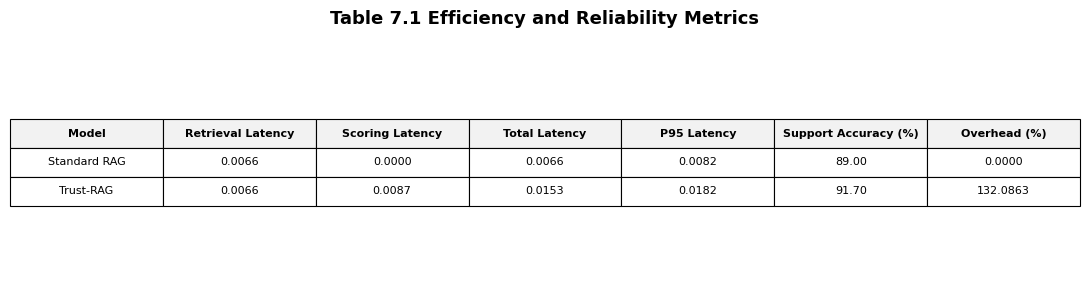

Saved: /kaggle/working/figures/rq7_table_7_1_efficiency_reliability_metrics.pdf


In [10]:
metrics_df = (
    stage_df
    .groupby("Model", as_index=False)
    .agg(
        Mean_Retrieval_Latency_sec=("Retrieval Latency", "mean"),
        Mean_Selection_Latency_sec=("Selection/Scoring Latency", "mean"),
        Mean_Total_Latency_sec=("Total Latency", "mean"),
        P95_Total_Latency_sec=("Total Latency", lambda x: np.percentile(x, 95)),
        Evidence_Support_Accuracy_pct=("Supported", lambda x: 100 * np.mean(x))
    )
)

std_latency = metrics_df[metrics_df["Model"] == "Standard RAG"]["Mean_Total_Latency_sec"].iloc[0]
metrics_df["Latency_Overhead_vs_Standard_pct"] = (
    (metrics_df["Mean_Total_Latency_sec"] - std_latency) / max(std_latency, 1e-8)
) * 100

metrics_path = os.path.join(TABLE_DIR, "rq7_table_7_1_efficiency_reliability_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")

table_preview = metrics_df.copy()
for col in [
    "Mean_Retrieval_Latency_sec",
    "Mean_Selection_Latency_sec",
    "Mean_Total_Latency_sec",
    "P95_Total_Latency_sec",
    "Evidence_Support_Accuracy_pct",
    "Latency_Overhead_vs_Standard_pct"
]:
    table_preview[col] = table_preview[col].map(lambda x: f"{x:.4f}" if "Latency" in col else f"{x:.2f}")

table_preview.columns = [
    "Model",
    "Retrieval Latency",
    "Scoring Latency",
    "Total Latency",
    "P95 Latency",
    "Support Accuracy (%)",
    "Overhead (%)"
]

tbl = ax.table(
    cellText=table_preview.values,
    colLabels=table_preview.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.7)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

plt.title("Table 7.1 Efficiency and Reliability Metrics", fontsize=13, fontweight="bold", pad=15)
savefig("rq7_table_7_1_efficiency_reliability_metrics.pdf")

## 7. Fig 7.1 — Latency Comparison by Pipeline Stage

Saved: /kaggle/working/tables/rq7_fig_7_1_latency_by_stage.csv


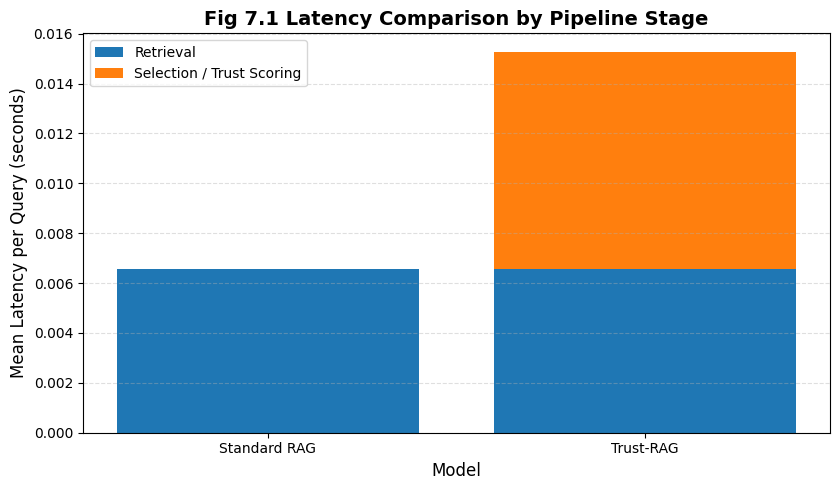

Saved: /kaggle/working/figures/rq7_fig_7_1_latency_by_stage.pdf


In [11]:
fig71_df = metrics_df.copy()

fig71_path = os.path.join(TABLE_DIR, "rq7_fig_7_1_latency_by_stage.csv")
fig71_df.to_csv(fig71_path, index=False)
print("Saved:", fig71_path)

models = fig71_df["Model"].tolist()
retrieval_vals = fig71_df["Mean_Retrieval_Latency_sec"].values
scoring_vals = fig71_df["Mean_Selection_Latency_sec"].values

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.bar(x, retrieval_vals, label="Retrieval")
ax.bar(x, scoring_vals, bottom=retrieval_vals, label="Selection / Trust Scoring")

ax.set_title("Fig 7.1 Latency Comparison by Pipeline Stage", fontsize=14, fontweight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Mean Latency per Query (seconds)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

savefig("rq7_fig_7_1_latency_by_stage.pdf")

## 8. Scalability with sample size

In [12]:
scalability_rows = []

max_size = min(max(SCALABILITY_SAMPLE_SIZES), len(examples))

for n in SCALABILITY_SAMPLE_SIZES:
    if n > len(examples):
        continue

    sub_examples = examples[:n]

    t0 = time.time()
    std_supported = []
    for ex in sub_examples:
        docs = retrieve_documents(ex["question"], top_k=MAIN_RETRIEVAL_K)
        selected = select_standard_rag(docs, SELECTED_CONTEXT_K)
        std_supported.append(evidence_supports_answer(ex["answers"], selected))
    std_total = time.time() - t0

    t1 = time.time()
    trust_supported = []
    for ex in sub_examples:
        docs = retrieve_documents(ex["question"], top_k=MAIN_RETRIEVAL_K)
        selected = select_trust_rag(ex["question"], docs, SELECTED_CONTEXT_K)
        trust_supported.append(evidence_supports_answer(ex["answers"], selected))
    trust_total = time.time() - t1

    scalability_rows.extend([
        {
            "Sample Size": n,
            "Model": "Standard RAG",
            "Total Runtime_sec": std_total,
            "Runtime_per_Query_sec": std_total / n,
            "Evidence_Support_Accuracy_pct": 100 * np.mean(std_supported)
        },
        {
            "Sample Size": n,
            "Model": "Trust-RAG",
            "Total Runtime_sec": trust_total,
            "Runtime_per_Query_sec": trust_total / n,
            "Evidence_Support_Accuracy_pct": 100 * np.mean(trust_supported)
        }
    ])

scalability_df = pd.DataFrame(scalability_rows)

scalability_path = os.path.join(TABLE_DIR, "rq7_scalability_results.csv")
scalability_df.to_csv(scalability_path, index=False)

display(scalability_df)
print("Saved:", scalability_path)

,Sample Size,Model,Total Runtime_sec,Runtime_per_Query_sec,Evidence_Support_Accuracy_pct
0,100,Standard RAG,0.620005,0.006200,84.000000
1,100,Trust-RAG,1.573910,0.015739,90.000000
2,250,Standard RAG,1.569101,0.006276,87.200000
3,250,Trust-RAG,3.772744,0.015091,93.200000
4,500,Standard RAG,3.213511,0.006427,89.200000
5,500,Trust-RAG,7.436571,0.014873,93.000000
6,750,Standard RAG,4.730501,0.006307,90.266667
7,750,Trust-RAG,11.300879,0.015068,93.733333
8,1000,Standard RAG,6.252018,0.006252,89.000000
9,1000,Trust-RAG,15.657040,0.015657,91.700000


Saved: /kaggle/working/tables/rq7_scalability_results.csv


## 9. Fig 7.2 — Scalability with Sample Size

Saved: /kaggle/working/tables/rq7_fig_7_2_scalability_with_sample_size.csv


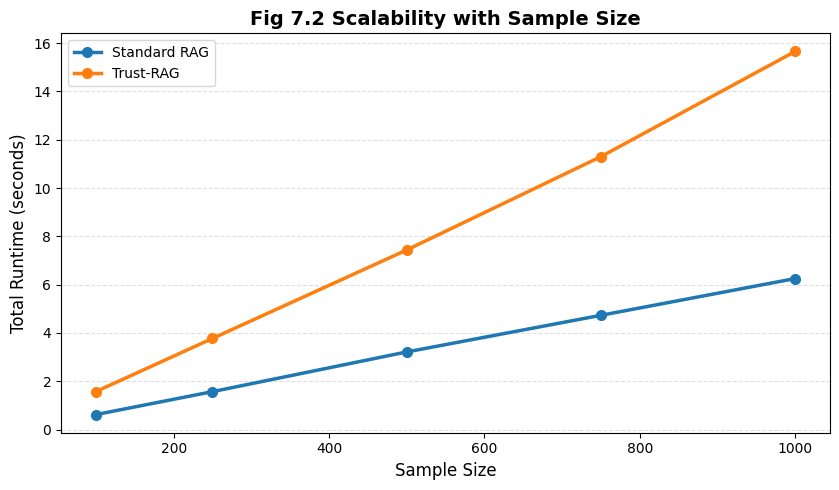

Saved: /kaggle/working/figures/rq7_fig_7_2_scalability_with_sample_size.pdf


In [13]:
fig72_path = os.path.join(TABLE_DIR, "rq7_fig_7_2_scalability_with_sample_size.csv")
scalability_df.to_csv(fig72_path, index=False)
print("Saved:", fig72_path)

fig, ax = plt.subplots(figsize=(8.5, 5))

for model_name in ["Standard RAG", "Trust-RAG"]:
    sub = scalability_df[scalability_df["Model"] == model_name].sort_values("Sample Size")
    ax.plot(
        sub["Sample Size"],
        sub["Total Runtime_sec"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=model_name
    )

ax.set_title("Fig 7.2 Scalability with Sample Size", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample Size", fontsize=12)
ax.set_ylabel("Total Runtime (seconds)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

savefig("rq7_fig_7_2_scalability_with_sample_size.pdf")

## 10. Retrieval-depth efficiency experiment

In [14]:
k_rows = []

for k in RETRIEVAL_K_VALUES:
    for ex in tqdm(examples, desc=f"Retrieval depth k={k}", leave=False):
        docs = retrieve_documents(ex["question"], top_k=k)

        t0 = time.time()
        std_docs = select_standard_rag(docs, min(SELECTED_CONTEXT_K, k))
        std_time = time.time() - t0

        t1 = time.time()
        trust_docs = select_trust_rag(ex["question"], docs, min(SELECTED_CONTEXT_K, k))
        trust_time = time.time() - t1

        k_rows.extend([
            {
                "Retrieval_K": k,
                "Model": "Standard RAG",
                "Selection_Time_sec": std_time,
                "Supported": int(evidence_supports_answer(ex["answers"], std_docs))
            },
            {
                "Retrieval_K": k,
                "Model": "Trust-RAG",
                "Selection_Time_sec": trust_time,
                "Supported": int(evidence_supports_answer(ex["answers"], trust_docs))
            }
        ])

k_df = pd.DataFrame(k_rows)

k_summary = (
    k_df
    .groupby(["Retrieval_K", "Model"], as_index=False)
    .agg(
        Mean_Selection_Time_sec=("Selection_Time_sec", "mean"),
        Support_Accuracy_pct=("Supported", lambda x: 100 * np.mean(x))
    )
)

k_path = os.path.join(TABLE_DIR, "rq7_retrieval_depth_results.csv")
k_summary.to_csv(k_path, index=False)

display(k_summary)
print("Saved:", k_path)

Retrieval depth k=3:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieval depth k=5:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieval depth k=8:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieval depth k=10:   0%|          | 0/1000 [00:00<?, ?it/s]

,Retrieval_K,Model,Mean_Selection_Time_sec,Support_Accuracy_pct
0,3,Standard RAG,0.000004,89.0
1,3,Trust-RAG,0.001201,89.0
2,5,Standard RAG,0.000004,89.0
3,5,Trust-RAG,0.003379,90.8
4,8,Standard RAG,0.000004,89.0
5,8,Trust-RAG,0.008826,91.7
6,10,Standard RAG,0.000004,89.0
7,10,Trust-RAG,0.013806,91.9


Saved: /kaggle/working/tables/rq7_retrieval_depth_results.csv


## 11. Fig 7.3 — Reliability–Efficiency Trade-off

Saved: /kaggle/working/tables/rq7_fig_7_3_reliability_efficiency_tradeoff.csv


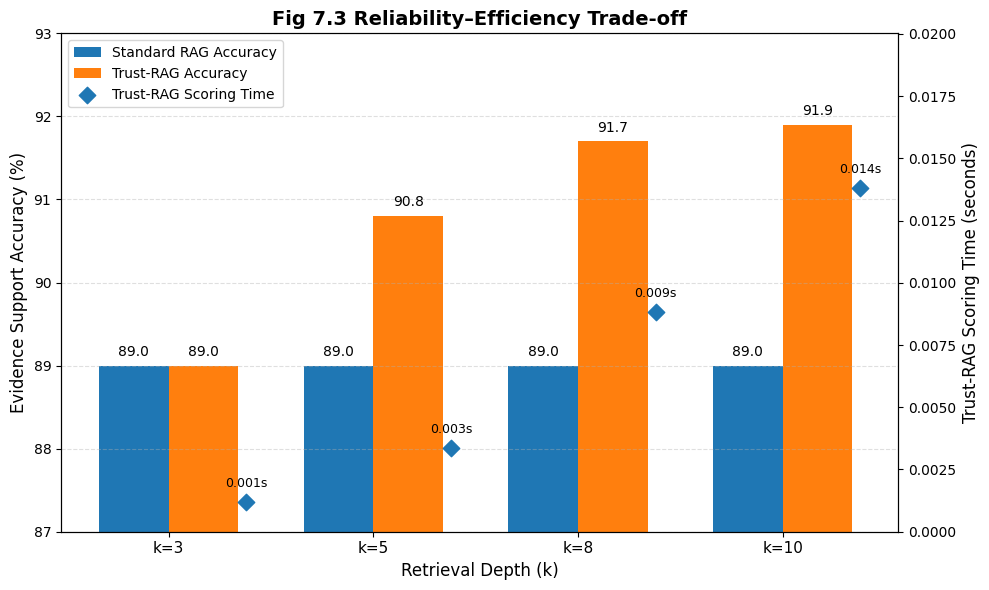

Saved: /kaggle/working/figures/rq7_fig_7_3_reliability_efficiency_tradeoff.pdf


In [15]:
# Fig 7.3 — Reliability–Efficiency Trade-off
# Final clean thesis-ready version
# Accuracy = grouped bars
# Scoring time = separate right-axis markers, no crossing line

fig73_df = k_summary.copy()

fig73_path = os.path.join(TABLE_DIR, "rq7_fig_7_3_reliability_efficiency_tradeoff.csv")
fig73_df.to_csv(fig73_path, index=False)
print("Saved:", fig73_path)

# Prepare data from k_summary
std = fig73_df[fig73_df["Model"] == "Standard RAG"].sort_values("Retrieval_K")
trust = fig73_df[fig73_df["Model"] == "Trust-RAG"].sort_values("Retrieval_K")

k_values = std["Retrieval_K"].values
x = np.arange(len(k_values))
bar_width = 0.34

fig, ax1 = plt.subplots(figsize=(10, 6))

# -----------------------------
# Accuracy bars
# -----------------------------
bars_std = ax1.bar(
    x - bar_width / 2,
    std["Support_Accuracy_pct"],
    width=bar_width,
    label="Standard RAG Accuracy"
)

bars_trust = ax1.bar(
    x + bar_width / 2,
    trust["Support_Accuracy_pct"],
    width=bar_width,
    label="Trust-RAG Accuracy"
)

ax1.set_title(
    "Fig 7.3 Reliability–Efficiency Trade-off",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Retrieval Depth (k)", fontsize=12)
ax1.set_ylabel("Evidence Support Accuracy (%)", fontsize=12)

ax1.set_xticks(x)
ax1.set_xticklabels([f"k={k}" for k in k_values], fontsize=11)

# Zoom into useful range so accuracy differences are visible
ax1.set_ylim(87, 93)

ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Accuracy labels above bars
for bars in [bars_std, bars_trust]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.08,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

# -----------------------------
# Secondary axis: scoring time
# -----------------------------
ax2 = ax1.twinx()

# Place scoring-time markers between the paired bars
marker_x = x + 0.38

ax2.scatter(
    marker_x,
    trust["Mean_Selection_Time_sec"],
    marker="D",
    s=70,
    label="Trust-RAG Scoring Time"
)

ax2.set_ylabel("Trust-RAG Scoring Time (seconds)", fontsize=12)

# Give enough headroom for labels
max_time = trust["Mean_Selection_Time_sec"].max()
ax2.set_ylim(0, max_time * 1.45)

# Scoring-time labels
for xi, yi in zip(marker_x, trust["Mean_Selection_Time_sec"]):
    ax2.text(
        xi,
        yi + max_time * 0.035,
        f"{yi:.3f}s",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -----------------------------
# Combined legend
# -----------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=10
)

savefig("rq7_fig_7_3_reliability_efficiency_tradeoff.pdf")

## 12. Final RQ7 summary

In [16]:
std = metrics_df[metrics_df["Model"] == "Standard RAG"].iloc[0]
trust = metrics_df[metrics_df["Model"] == "Trust-RAG"].iloc[0]

accuracy_gain = trust["Evidence_Support_Accuracy_pct"] - std["Evidence_Support_Accuracy_pct"]
latency_overhead = trust["Latency_Overhead_vs_Standard_pct"]

print("=== RQ7 Final Summary ===")
print(f"Standard RAG accuracy: {std['Evidence_Support_Accuracy_pct']:.2f}%")
print(f"Trust-RAG accuracy: {trust['Evidence_Support_Accuracy_pct']:.2f}%")
print(f"Accuracy gain: {accuracy_gain:.2f} percentage points")

print(f"Standard RAG mean latency: {std['Mean_Total_Latency_sec']:.5f} sec/query")
print(f"Trust-RAG mean latency: {trust['Mean_Total_Latency_sec']:.5f} sec/query")
print(f"Latency overhead: {latency_overhead:.2f}%")

if accuracy_gain > 0:
    print("\nResult: Trust-RAG improves evidence support accuracy with measurable but practical scoring overhead.")
else:
    print("\nCheck result: Trust-RAG did not improve support accuracy in this run.")

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.startswith("rq7_"):
        print("-", f)

print("\nGenerated tables:")
for f in sorted(os.listdir(TABLE_DIR)):
    if f.startswith("rq7_"):
        print("-", f)

=== RQ7 Final Summary ===
Standard RAG accuracy: 89.00%
Trust-RAG accuracy: 91.70%
Accuracy gain: 2.70 percentage points
Standard RAG mean latency: 0.00657 sec/query
Trust-RAG mean latency: 0.01525 sec/query
Latency overhead: 132.09%

Result: Trust-RAG improves evidence support accuracy with measurable but practical scoring overhead.

Generated figures:
- rq7_fig_7_1_latency_by_stage.pdf
- rq7_fig_7_2_scalability_with_sample_size.pdf
- rq7_fig_7_3_reliability_efficiency_tradeoff.pdf
- rq7_table_7_1_efficiency_reliability_metrics.pdf

Generated tables:
- rq7_fig_7_1_latency_by_stage.csv
- rq7_fig_7_2_scalability_with_sample_size.csv
- rq7_fig_7_3_reliability_efficiency_tradeoff.csv
- rq7_prediction_results.csv
- rq7_retrieval_depth_results.csv
- rq7_scalability_results.csv
- rq7_stage_latency_results.csv
- rq7_table_7_1_efficiency_reliability_metrics.csv
